In [1]:
%pip install adjustText

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib.lines import Line2D

from adjustText import adjust_text

In [3]:
activity_files = {
    "SBS": "SBS/Assignment_Solution_Activities.txt",
    #"DBS": "DBS/Assignment_Solution_Activities.txt",
    #"ID": "ID/Assignment_Solution_Activities.txt"
}

signature_tables = {signature_type: pd.read_csv(path, sep="\t")
                    for signature_type, path in activity_files.items()}

for signature_type, table in signature_tables.items():
    if "Samples" not in table.columns:
        raise ValueError(f"Column 'Samples' was not found in the {signature_type} file.")

    signature_columns = [column for column in table.columns if column.startswith(signature_type)]
    if not signature_columns:
        raise ValueError(f"No {signature_type} signature columns were found.")

    print(f"{signature_type}: {len(table)} samples, {len(signature_columns)} signatures")

SBS: 100 samples, 17 signatures


In [4]:
comparisons = [
    {
        "pre_sample": "SYNG-BC1-1524-FIXT-02-DNA-01_vs_SYNG-BC1-1524-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1524-FIXT-01-DNA-01_vs_SYNG-BC1-1524-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment1.png"
    },
    {
        "pre_sample": "SYNG-BC1-1534-FIXT-02-DNA-01_vs_SYNG-BC1-1534-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1534-FIXT-01-DNA-01_vs_SYNG-BC1-1534-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment2.png"
    },
    {
        "pre_sample": "SYNG-BC1-1541-FIXT-02-DNA-01_vs_SYNG-BC1-1541-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1541-FIXT-01-DNA-01_vs_SYNG-BC1-1541-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment3.png"
    },
    {
        "pre_sample": "SYNG-BC1-1542-FIXT-02-DNA-01_vs_SYNG-BC1-1542-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1542-FIXT-01-DNA-01_vs_SYNG-BC1-1542-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment4.png"
    },
    {
        "pre_sample": "SYNG-BC1-1549-FIXT-02-DNA-01_vs_SYNG-BC1-1549-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1549-FIXT-01-DNA-01_vs_SYNG-BC1-1549-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment5.png"
    },
    {
        "pre_sample": "SYNG-BC1-1551-FIXT-02-DNA-01_vs_SYNG-BC1-1551-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1551-FIXT-01-DNA-01_vs_SYNG-BC1-1551-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment6.png"
    },
    {
        "pre_sample": "SYNG-BC1-1559-FIXT-02-DNA-01_vs_SYNG-BC1-1559-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1559-FIXT-01-DNA-01_vs_SYNG-BC1-1559-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment7.png"
    },
    {
        "pre_sample": "SYNG-BC1-1566-FIXT-02-DNA-01_vs_SYNG-BC1-1566-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1566-FIXT-01-DNA-01_vs_SYNG-BC1-1566-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment8.png"
    },
    {
        "pre_sample": "SYNG-BC1-1599-FIXT-02-DNA-01_vs_SYNG-BC1-1599-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1599-FIXT-01-DNA-01_vs_SYNG-BC1-1599-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment9.png"
    },
    {
        "pre_sample": "SYNG-BC1-1601-FIXT-02-DNA-01_vs_SYNG-BC1-1601-BL_OTHER-01-DNA-01",
        "post_sample": "SYNG-BC1-1601-FIXT-01-DNA-01_vs_SYNG-BC1-1601-BL_OTHER-01-DNA-01",
        "output": "pre_vs_post_treatment10.png"
    }
]


In [5]:
def get_activities(sample_name):
    activities = {}

    for signature_type, table in signature_tables.items():
        rows = table.loc[table["Samples"] == sample_name]

        if rows.empty:
            activities[signature_type] = None
            continue

        if len(rows) > 1:
            raise ValueError(f"Sample '{sample_name}' occurs more than once in the {signature_type} file.")

        signature_columns = [column for column in table.columns if column.startswith(signature_type)]
        activities[signature_type] = rows.iloc[0][signature_columns].astype(float)

    return activities

In [6]:
# def get_available_types(pre_data, post_data):
#     return [signature_type for signature_type in ["SBS", "DBS", "ID"]
#             if pre_data[signature_type] is not None and post_data[signature_type] is not None]

def get_available_types(pre_data, post_data):
    return [signature_type for signature_type in ["SBS"]
            if pre_data[signature_type] is not None and post_data[signature_type] is not None]


In [7]:
def make_comparison_table(pre_data, post_data):
    tables = []

    for signature_type in get_available_types(pre_data, post_data):
        df = pd.DataFrame({"Pre-treatment": pre_data[signature_type], "Post-treatment": post_data[signature_type]})
        df = df.loc[df.ne(0).any(axis=1)]
        df.insert(0, "Type", signature_type)
        df["Difference"] = df["Post-treatment"] - df["Pre-treatment"]
        df.index.name = "Signature"
        tables.append(df.reset_index())

    if not tables:
        return pd.DataFrame(columns=["Signature", "Type", "Pre-treatment", "Post-treatment", "Difference"])

    return pd.concat(tables, ignore_index=True)


In [8]:
def scatter_plot(pre_data, post_data, relative=False, save_path=None):
    available_types = get_available_types(pre_data, post_data)
    tables = []

    for signature_type in available_types:
        pre = pre_data[signature_type].copy()
        post = post_data[signature_type].copy()

        if relative:
            if pre.sum() > 0:
                pre = pre / pre.sum() * 100
            if post.sum() > 0:
                post = post / post.sum() * 100

        df_type = pd.DataFrame({"Pre-treatment": pre, "Post-treatment": post})
        df_type = df_type.loc[df_type.ne(0).any(axis=1)]
        tables.append(df_type)

    if not tables:
        raise ValueError("No signature data are available for both samples.")

    df = pd.concat(tables)
    if df.empty:
        raise ValueError("No active signatures were found in either sample.")

    signatures = df.index
    pre_values = df["Pre-treatment"].to_numpy()
    post_values = df["Post-treatment"].to_numpy()
    differences = post_values - pre_values

    plt.figure(figsize=(12, 8))
    colors = ["red" if difference > 0 else "blue" if difference < 0 else "gray" for difference in differences]
    plt.scatter(pre_values, post_values, c=colors, s=140, alpha=0.75, edgecolor="black")

    texts = [plt.text(x, y, signature, fontsize=12)
             for signature, x, y in zip(signatures, pre_values, post_values)]

    max_value = max(pre_values.max(), post_values.max())
    plt.plot([0, max_value], [0, max_value], "k--", alpha=0.3)

    axis_suffix = " (%)" if relative else ""
    activity_label = "Relative Signature Activity" if relative else "Signature Activity"

    plt.xlabel(f"Pre-treatment{axis_suffix}", fontsize=15, labelpad=10)
    plt.ylabel(f"Post-treatment{axis_suffix}", fontsize=15, labelpad=10)
    plt.title(f"{activity_label} - Pre-treatment vs Post-treatment", fontsize=14, fontweight="bold")

    plt.scatter([], [], c="red", s=120, label="Higher post-treatment")
    plt.scatter([], [], c="blue", s=120, label="Higher pre-treatment")
    plt.scatter([], [], c="gray", s=120, label="No change")
    plt.legend(fontsize=13)

    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    adjust_text(texts, x=pre_values, y=post_values, target_x=pre_values, target_y=post_values,
                expand=(1.2, 1.3), arrowprops=dict(arrowstyle="-", color="gray", lw=0.7))

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()



Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,154.0,0.0,-154.0
1,SBS5,SBS,1160.0,74.0,-1086.0
2,SBS32,SBS,365.0,0.0,-365.0


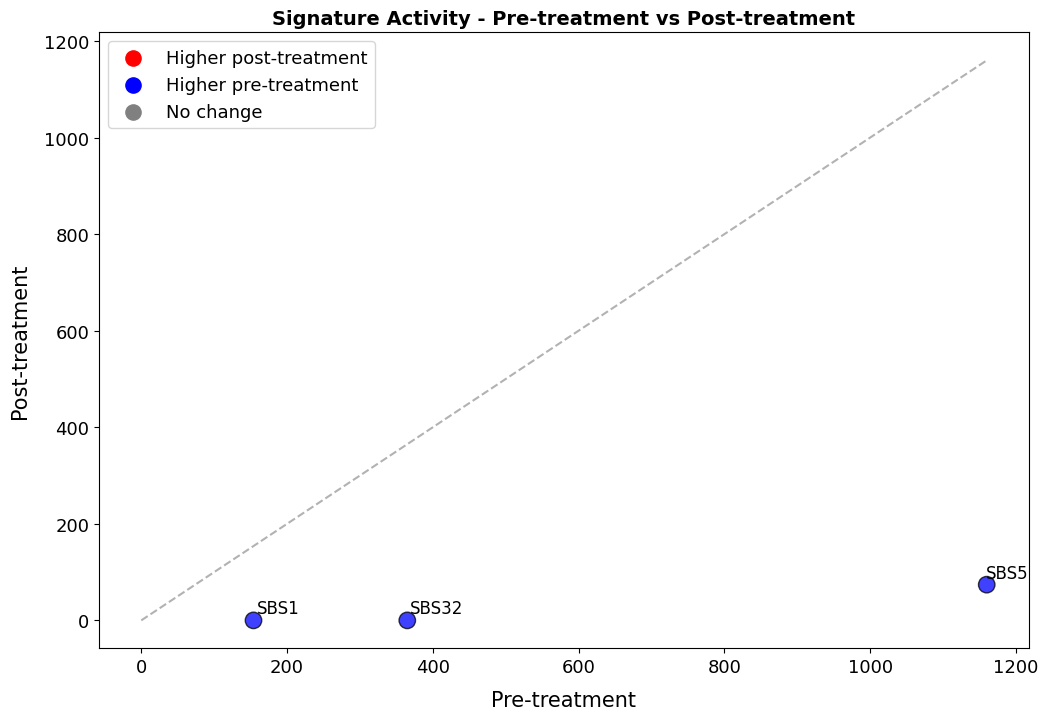


Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,16.0,19.0,3.0
1,SBS2,SBS,23.0,22.0,-1.0
2,SBS5,SBS,56.0,86.0,30.0
3,SBS13,SBS,45.0,47.0,2.0
4,SBS44,SBS,20.0,0.0,-20.0
5,SBS87,SBS,16.0,0.0,-16.0


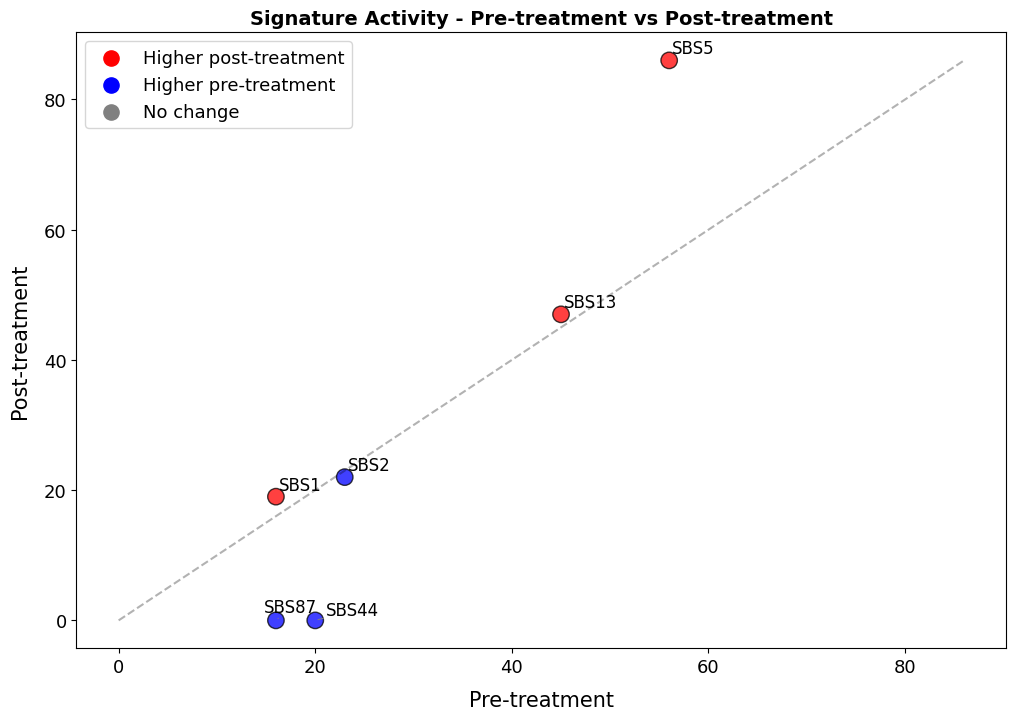


Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,36.0,45.0,9.0
1,SBS2,SBS,11.0,7.0,-4.0
2,SBS5,SBS,128.0,132.0,4.0
3,SBS13,SBS,19.0,20.0,1.0


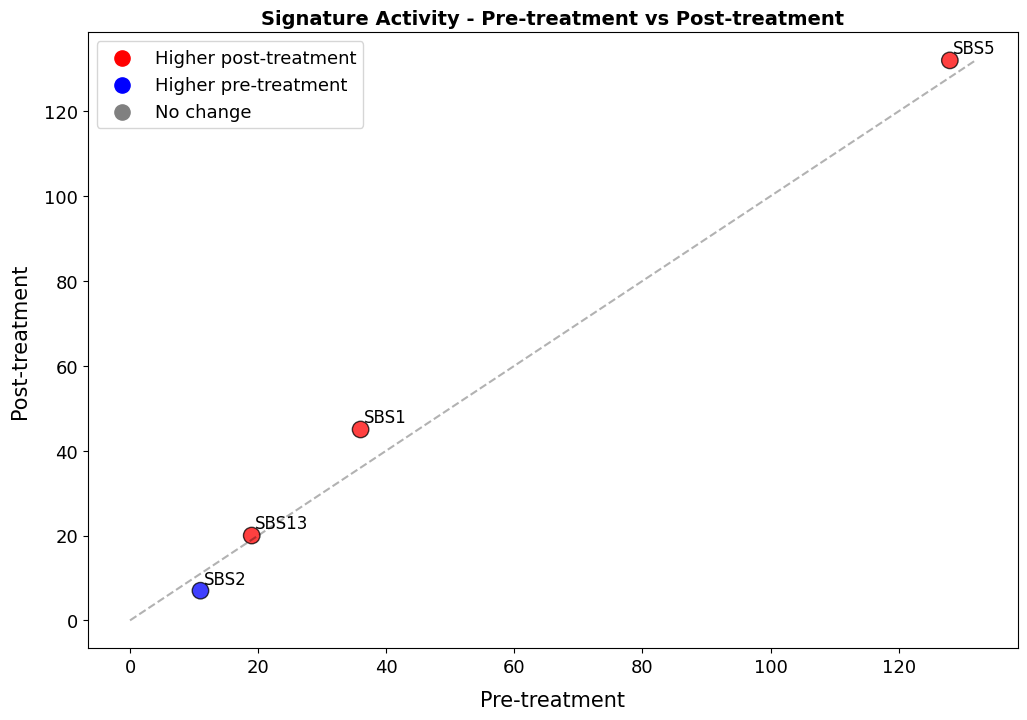


Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,11.0,3.0,-8.0
1,SBS5,SBS,125.0,48.0,-77.0
2,SBS6,SBS,55.0,0.0,-55.0
3,SBS19,SBS,55.0,0.0,-55.0
4,SBS32,SBS,88.0,0.0,-88.0
5,SBS87,SBS,0.0,9.0,9.0


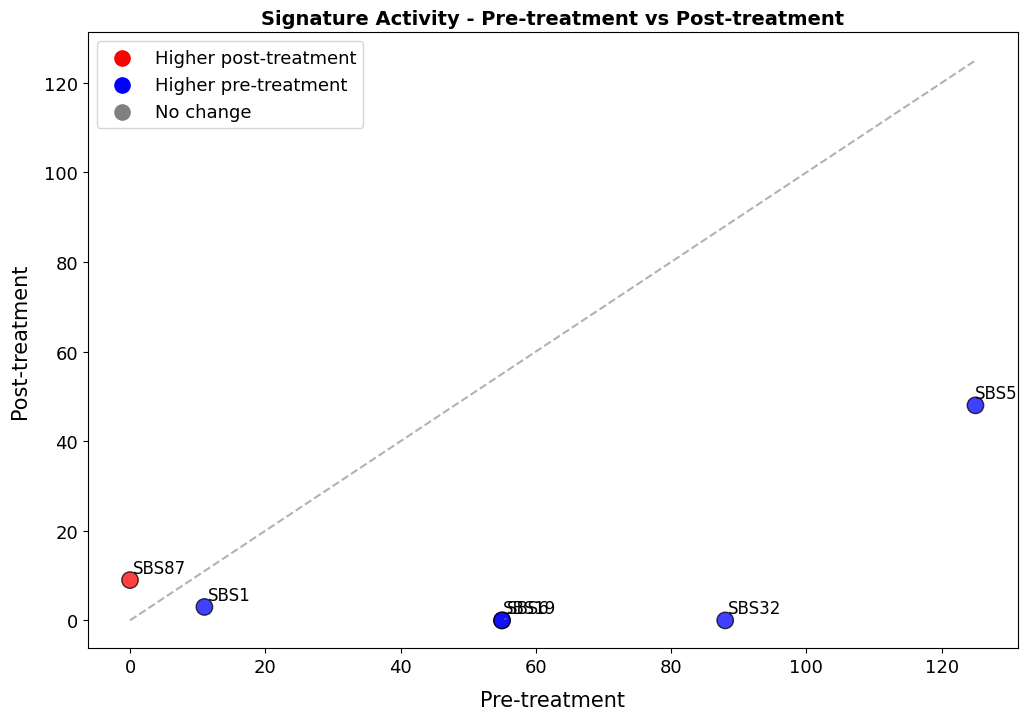


Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,33.0,37.0,4.0
1,SBS5,SBS,57.0,66.0,9.0


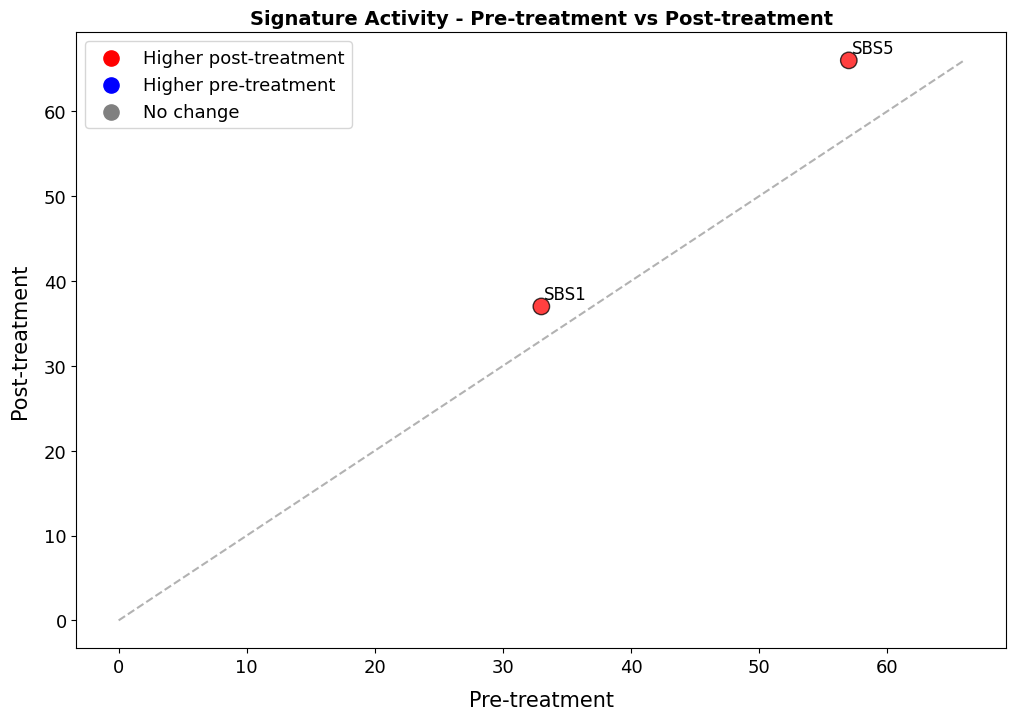


Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,22.0,26.0,4.0
1,SBS2,SBS,0.0,12.0,12.0
2,SBS3,SBS,0.0,42.0,42.0
3,SBS5,SBS,97.0,41.0,-56.0


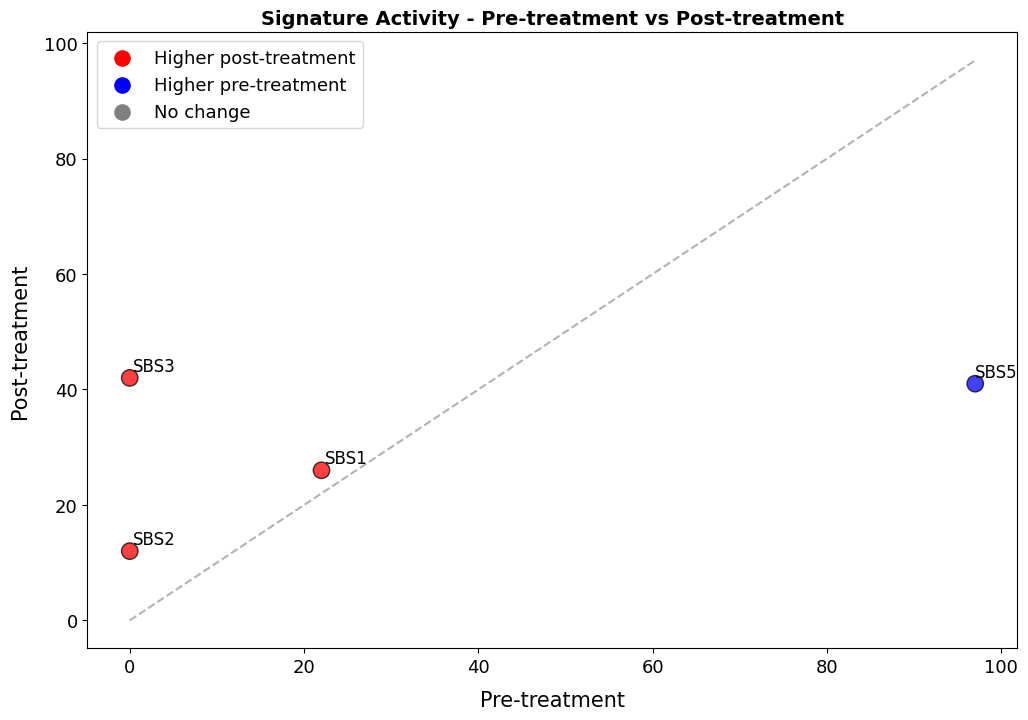


Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,15.0,0.0,-15.0
1,SBS5,SBS,65.0,55.0,-10.0
2,SBS6,SBS,0.0,11.0,11.0
3,SBS87,SBS,0.0,14.0,14.0


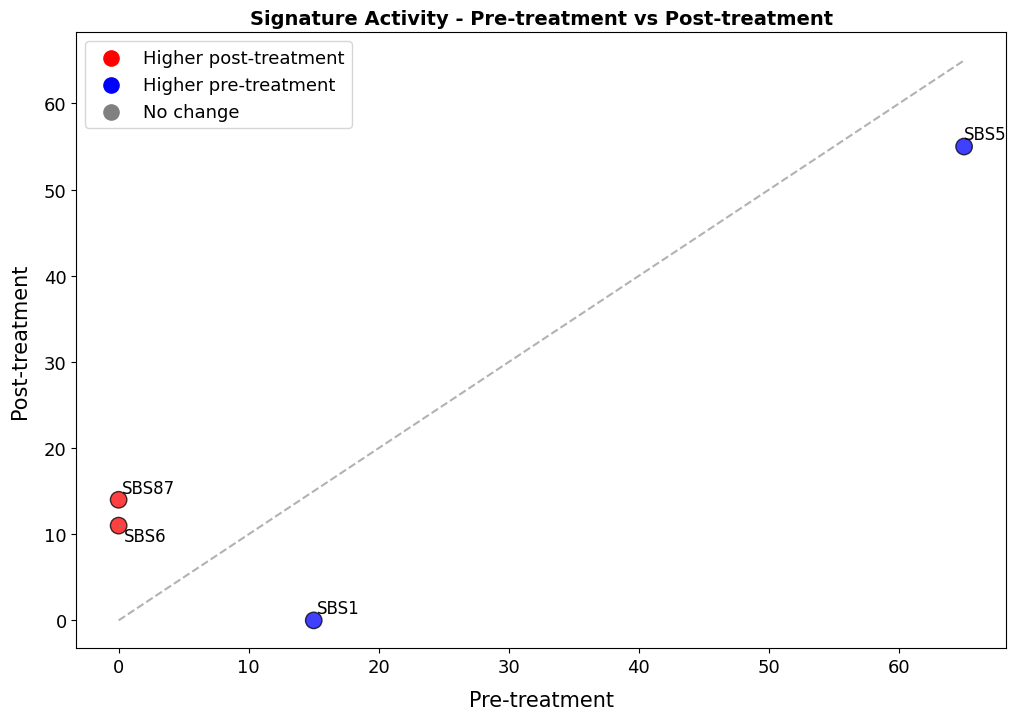


Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,14.0,23.0,9.0
1,SBS2,SBS,9.0,0.0,-9.0
2,SBS5,SBS,47.0,121.0,74.0
3,SBS15,SBS,13.0,0.0,-13.0
4,SBS31,SBS,22.0,0.0,-22.0
5,SBS96,SBS,33.0,0.0,-33.0


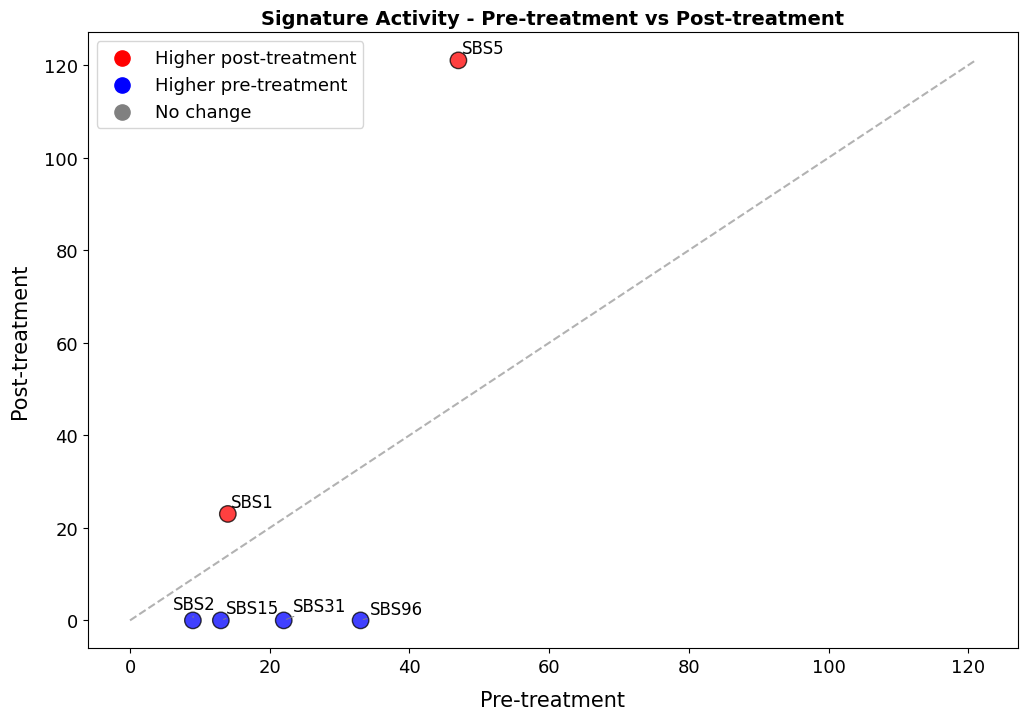


Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,114.0,118.0,4.0
1,SBS2,SBS,15.0,15.0,0.0
2,SBS5,SBS,42.0,45.0,3.0


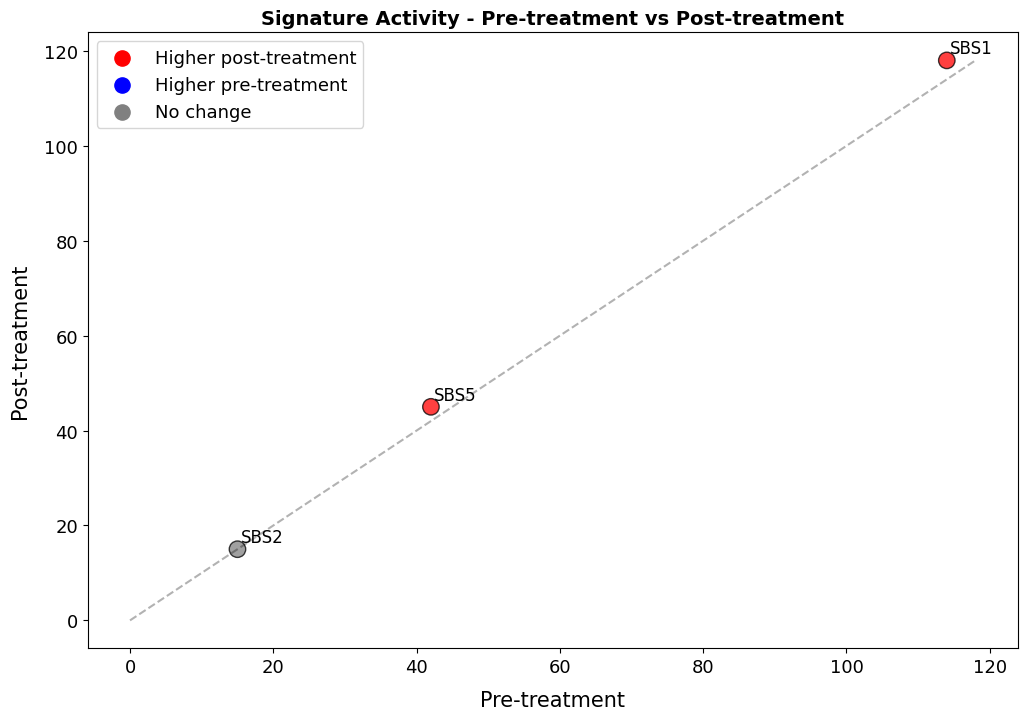


Pre-treatment vs post-treatment
Available signature types: SBS
Skipped due to missing sample data: DBS, ID


,Signature,Type,Pre-treatment,Post-treatment,Difference
0,SBS1,SBS,27.0,17.0,-10.0
1,SBS2,SBS,38.0,42.0,4.0
2,SBS5,SBS,119.0,99.0,-20.0
3,SBS13,SBS,58.0,61.0,3.0


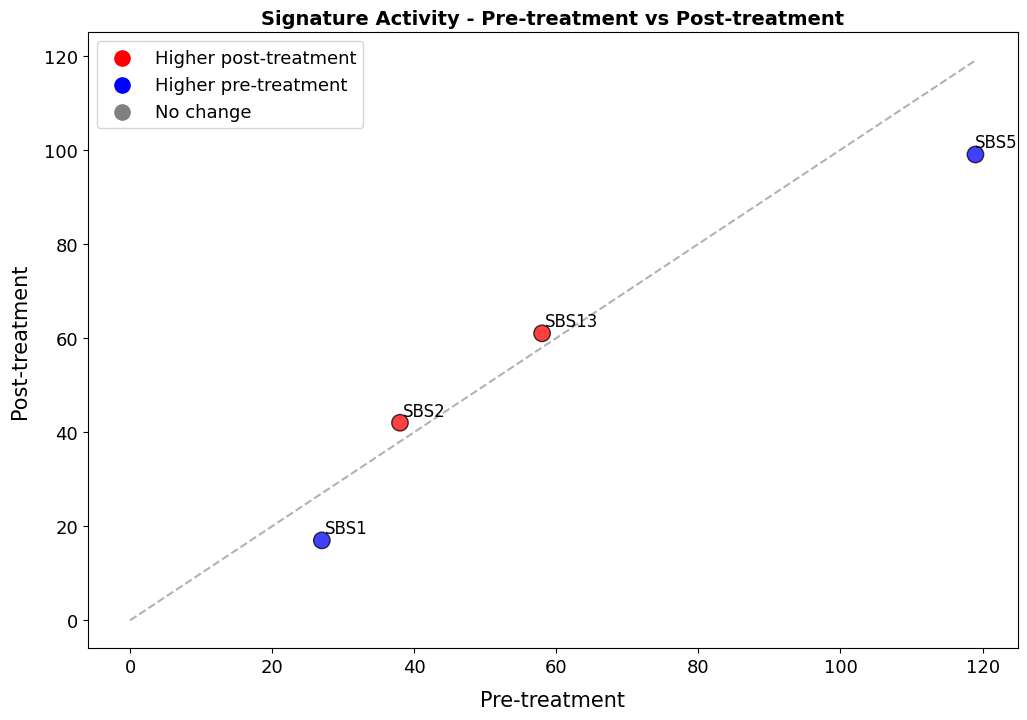

In [9]:
use_relative_activity = False

for comparison in comparisons:
    pre = get_activities(comparison["pre_sample"])
    post = get_activities(comparison["post_sample"])

    available_types = get_available_types(pre, post)
    unavailable_types = [signature_type for signature_type in ["SBS", "DBS", "ID"] if signature_type not in available_types]

    print("\nPre-treatment vs post-treatment")
    print(f'Available signature types: {", ".join(available_types)}')

    if unavailable_types:
        print(f'Skipped due to missing sample data: {", ".join(unavailable_types)}')

    display(make_comparison_table(pre, post))
    scatter_plot(pre, post, relative=use_relative_activity, save_path=comparison["output"])
